# Data-Driven Neural Network Baseline

This notebook develops a purely data-driven neural-network model for reconstructing the temperature field of the thermal system.

The model is trained only on sparse, noisy, and incomplete virtual sensor measurements.

The neural network approximates the temperature field as:

$$
T_\theta(x,t)
$$

where:

- $x$ is position along the rod
- $t$ is time
- $T_\theta$ is the temperature predicted by the neural network
- $\theta$ represents the trainable model parameters

The baseline model does not receive the governing heat equation.

Its predictions are therefore determined entirely from the available sensor measurements.

The complete numerical temperature field generated by the FTCS solver is retained only as ground truth for evaluating the reconstructed field.

This baseline will later be compared with a Physics-Informed Neural Network (PINN).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## 1. Loading the Sensor Measurements

The training data consist of five virtual temperature sensors positioned along the rod.

The measurements contain:

- Gaussian measurement noise
- missing observations
- only a small subset of the complete spatial temperature field

Each available measurement can be represented as a supervised training example:

$$
(x,t) \rightarrow T_{\text{measured}}
$$

Measurements that are missing are excluded from the training dataset.

In [2]:
sensor_df = pd.read_csv(
    "../data/thermal_sensor_data.csv"
)

sensor_df.head()

,time_s,sensor_0.20m,sensor_0.35m,sensor_0.50m,sensor_0.65m,sensor_0.80m
0,0.000000,20.319063,33.724598,100.323844,34.555245,19.953629
1,0.701754,19.963949,34.962053,99.511857,33.937709,20.352297
2,1.403509,NaN,34.308799,98.405535,33.585024,19.229874
3,2.105263,19.823547,34.395007,97.624852,34.447411,19.398539
4,2.807018,20.850951,35.138902,96.710022,34.539417,19.845936


## 2. Reshaping the Sensor Data

The sensor dataset is initially stored in wide format, where each sensor has its own column.

For neural-network training, the measurements are converted into individual spatiotemporal observations:

$$
(x_j,t_n,T_{j,n})
$$

Each row of the resulting training dataset contains:

- sensor position $x$
- measurement time $t$
- measured temperature $T$

Missing measurements are removed because they do not provide a valid target temperature.

In [3]:
sensor_positions = {
    "sensor_0.20m": 0.20,
    "sensor_0.35m": 0.35,
    "sensor_0.50m": 0.50,
    "sensor_0.65m": 0.65,
    "sensor_0.80m": 0.80
}

In [4]:
training_rows = []

for sensor_name, position in sensor_positions.items():

    for row_index in range(len(sensor_df)):

        time_value = sensor_df.loc[row_index, "time_s"]
        temperature_value = sensor_df.loc[row_index, sensor_name]

        if not pd.isna(temperature_value):

            training_rows.append(
                [
                    position,
                    time_value,
                    temperature_value
                ]
            )

In [5]:
training_df = pd.DataFrame(
    training_rows,
    columns=[
        "x",
        "time_s",
        "temperature_C"
    ]
)

training_df.head(10)

,x,time_s,temperature_C
0,0.2,0.000000,20.319063
1,0.2,0.701754,19.963949
2,0.2,2.105263,19.823547
3,0.2,2.807018,20.850951
4,0.2,3.508772,20.188134
5,0.2,4.210526,19.847504
6,0.2,4.912281,19.554784
7,0.2,5.614035,20.552473
8,0.2,6.315789,19.842554
9,0.2,7.017544,20.384973


In [6]:
print("Number of available training observations:", len(training_df))

training_df.head()

Number of available training observations: 1351


,x,time_s,temperature_C
0,0.2,0.000000,20.319063
1,0.2,0.701754,19.963949
2,0.2,2.105263,19.823547
3,0.2,2.807018,20.850951
4,0.2,3.508772,20.188134


## 3. Normalizing the Training Data

The input variables have different numerical ranges.

Position is measured in meters and lies between approximately $0$ and $1$, while time extends from $0$ to $200$ seconds. Temperature also has a different numerical range.

Neural networks generally train more effectively when the input and output variables have comparable scales.

Min-max normalization is therefore used:

$$
z_{\text{norm}}
=
\frac{z-z_{\min}}
{z_{\max}-z_{\min}}
$$

This transforms a variable into a range between approximately $0$ and $1$.

The original physical values are retained so that predictions can later be converted back to meters, seconds, and degrees Celsius.

In [7]:
x_min = 0.0
x_max = 1.0

t_min = training_df["time_s"].min()
t_max = training_df["time_s"].max()

T_min = training_df["temperature_C"].min()
T_max = training_df["temperature_C"].max()

In [8]:
training_df["x_norm"] = (
    training_df["x"] - x_min
) / (x_max - x_min)

training_df["time_norm"] = (
    training_df["time_s"] - t_min
) / (t_max - t_min)

training_df["temperature_norm"] = (
    training_df["temperature_C"] - T_min
) / (T_max - T_min)

In [9]:
training_df.head(10)

,x,time_s,temperature_C,x_norm,time_norm,temperature_norm
0,0.2,0.000000,20.319063,0.2,0.000000,0.016132
1,0.2,0.701754,19.963949,0.2,0.003509,0.011765
2,0.2,2.105263,19.823547,0.2,0.010526,0.010039
3,0.2,2.807018,20.850951,0.2,0.014035,0.022673
4,0.2,3.508772,20.188134,0.2,0.017544,0.014522
5,0.2,4.210526,19.847504,0.2,0.021053,0.010333
6,0.2,4.912281,19.554784,0.2,0.024561,0.006733
7,0.2,5.614035,20.552473,0.2,0.028070,0.019003
8,0.2,6.315789,19.842554,0.2,0.031579,0.010272
9,0.2,7.017544,20.384973,0.2,0.035088,0.016943


## 4. Converting the Training Data to PyTorch Tensors

PyTorch neural networks operate on tensors.

For each available sensor measurement, the model receives two inputs:

$$
X=(x,t)
$$

and one target value:

$$
y=T
$$

The normalized position and time are therefore combined into the input tensor, while the normalized temperature is stored in a separate target tensor.

In [10]:
X = training_df[
    ["x_norm", "time_norm"]
].values

y = training_df[
    ["temperature_norm"]
].values

In [11]:
X_tensor = torch.tensor(
    X,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y,
    dtype=torch.float32
)

In [12]:
print("X tensor shape:", X_tensor.shape)
print("y tensor shape:", y_tensor.shape)

print("\nFirst 5 inputs:")
print(X_tensor[:5])

print("\nFirst 5 targets:")
print(y_tensor[:5])

X tensor shape: torch.Size([1351, 2])
y tensor shape: torch.Size([1351, 1])

First 5 inputs:
tensor([[0.2000, 0.0000],
        [0.2000, 0.0035],
        [0.2000, 0.0105],
        [0.2000, 0.0140],
        [0.2000, 0.0175]])

First 5 targets:
tensor([[0.0161],
        [0.0118],
        [0.0100],
        [0.0227],
        [0.0145]])


## 5. Neural Network Architecture

A fully connected neural network is used to approximate the temperature field:

$$
T_\theta(x,t)
$$

The network receives two inputs:

$$
(x,t)
$$

and produces one output:

$$
\hat{T}
$$

where $\hat{T}$ is the predicted normalized temperature.

The network contains three hidden layers with 64 neurons each.

The hyperbolic tangent activation function (`Tanh`) is used because the temperature field is a smooth function of space and time. The same type of architecture can later be used for the Physics-Informed Neural Network, allowing a fair comparison between the data-driven and physics-informed approaches.

In [13]:
torch.manual_seed(42)

class TemperatureNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [14]:
model = TemperatureNN()

print(model)

TemperatureNN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [15]:
total_parameters = sum(
    p.numel() for p in model.parameters()
)

print("Total trainable parameters:", total_parameters)

Total trainable parameters: 8577


## 6. Train and Validation Split

The available sensor observations are divided into two groups:

- a training set used to update the neural-network parameters
- a validation set used to evaluate the model on observations that are not used for parameter updates

An 80/20 split is used:

$$
80\% \text{ training}
$$

$$
20\% \text{ validation}
$$

The validation set helps us check whether the model is learning a general relationship between position, time, and temperature rather than only fitting the observations used during training.

In [16]:
torch.manual_seed(42)

num_samples = X_tensor.shape[0]

indices = torch.randperm(num_samples)

train_size = int(0.8 * num_samples)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train = X_tensor[train_indices]
y_train = y_tensor[train_indices]

X_val = X_tensor[val_indices]
y_val = y_tensor[val_indices]

In [17]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Training samples: 1080
Validation samples: 271
X_train shape: torch.Size([1080, 2])
y_train shape: torch.Size([1080, 1])
X_val shape: torch.Size([271, 2])
y_val shape: torch.Size([271, 1])


## 7. Loss Function, Optimizer, and Learning-Rate Scheduler

The neural network learns by minimizing the difference between its predicted temperatures and the measured sensor temperatures.

Mean Squared Error (MSE) is used as the loss function:

$$
\mathcal{L}_{data}
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{T}_i-T_i)^2
$$

The Adam optimizer updates the neural-network weights and biases using gradients calculated through backpropagation.

A learning-rate scheduler is also used. If the validation loss stops improving for a period of time, the scheduler reduces the learning rate so that the optimizer can make smaller adjustments during later stages of training.

In [18]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=200
)

## 8. Training with Validation and Early Stopping

The model is trained using only the training observations.

After each epoch, its performance is also evaluated on the validation set. The validation observations are not used to update the neural-network parameters.

Early stopping is used to stop training when the validation loss no longer improves for a specified number of epochs.

The model parameters corresponding to the lowest validation loss are saved and restored after training.

In [19]:
import copy

max_epochs = 5000
early_stopping_patience = 500

train_loss_history = []
val_loss_history = []

best_val_loss = float("inf")
best_model_state = None

epochs_without_improvement = 0

In [20]:
for epoch in range(max_epochs):

    # ----- Training -----

    model.train()

    predictions_train = model(X_train)

    train_loss = loss_function(
        predictions_train,
        y_train
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()


    # ----- Validation -----

    model.eval()

    with torch.no_grad():

        predictions_val = model(X_val)

        val_loss = loss_function(
            predictions_val,
            y_val
        )


    # Store loss values
    train_loss_history.append(
        train_loss.item()
    )

    val_loss_history.append(
        val_loss.item()
    )


    # Update learning-rate scheduler
    scheduler.step(val_loss)


    # ----- Check for improvement -----

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # ----- Early stopping -----

    if epochs_without_improvement >= early_stopping_patience:

        print(
            f"Early stopping at epoch {epoch + 1}"
        )

        break


    # Print progress
    if (epoch + 1) % 500 == 0:

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch + 1}, "
            f"Train Loss: {train_loss.item():.6f}, "
            f"Val Loss: {val_loss.item():.6f}, "
            f"LR: {current_lr:.6f}"
        )

Epoch 500, Train Loss: 0.001761, Val Loss: 0.002370, LR: 0.001000
Epoch 1000, Train Loss: 0.000271, Val Loss: 0.000393, LR: 0.001000
Epoch 1500, Train Loss: 0.000125, Val Loss: 0.000160, LR: 0.001000
Epoch 2000, Train Loss: 0.000102, Val Loss: 0.000123, LR: 0.001000
Epoch 2500, Train Loss: 0.000073, Val Loss: 0.000096, LR: 0.001000
Epoch 3000, Train Loss: 0.000063, Val Loss: 0.000084, LR: 0.001000
Epoch 3500, Train Loss: 0.000058, Val Loss: 0.000077, LR: 0.001000
Epoch 4000, Train Loss: 0.000054, Val Loss: 0.000071, LR: 0.001000
Epoch 4500, Train Loss: 0.000102, Val Loss: 0.000128, LR: 0.001000
Epoch 5000, Train Loss: 0.000046, Val Loss: 0.000061, LR: 0.001000


## 9. Training and Validation Loss

Training and validation losses are compared to evaluate the learning behavior of the neural network.

A decreasing training loss indicates that the model is fitting the available sensor observations.

The validation loss measures performance on observations that were not used for parameter updates.

If training loss continues decreasing while validation loss begins increasing consistently, this can indicate overfitting.

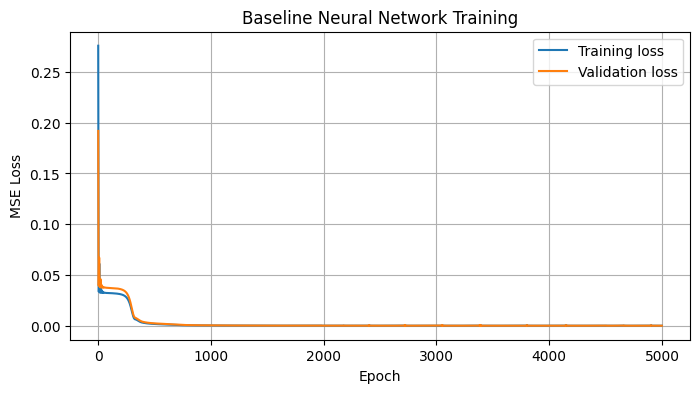

In [21]:
plt.figure(figsize=(8, 4))

plt.plot(
    train_loss_history,
    label="Training loss"
)

plt.plot(
    val_loss_history,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Baseline Neural Network Training")

plt.legend()
plt.grid()
plt.show()

In [22]:
best_epoch = np.argmin(val_loss_history) + 1

print("Best epoch:", best_epoch)
print("Best validation loss:", min(val_loss_history))

Best epoch: 4968
Best validation loss: 6.112774281064048e-05


## 10. Full-Field Temperature Reconstruction

The trained neural network has only observed measurements from five sensor locations.

The model is now evaluated over the complete spatial and temporal domain.

For every combination of position and time, the network predicts:

$$
\hat{T}(x,t)
$$

These predictions are compared with the complete numerical temperature field generated by the validated heat-equation solver.

This provides a stronger test of the data-driven model because most spatial positions were never directly observed during training.

In [28]:
reference_data = np.load(
    "../data/reference_temperature_field.npz"
)

x_full = reference_data["x"]
time_full = reference_data["time"]
T_true_full = reference_data["temperature_field"]

print("x shape:", x_full.shape)
print("time shape:", time_full.shape)
print("Temperature field shape:", T_true_full.shape)

x shape: (81,)
time shape: (286,)
Temperature field shape: (286, 81)


In [29]:
x_grid, time_grid = np.meshgrid(
    x_full,
    time_full
)

x_flat = x_grid.reshape(-1, 1)
time_flat = time_grid.reshape(-1, 1)

print("x_grid shape:", x_grid.shape)
print("time_grid shape:", time_grid.shape)

x_grid shape: (286, 81)
time_grid shape: (286, 81)


In [30]:
x_flat_norm = (
    x_flat - x_min
) / (x_max - x_min)

time_flat_norm = (
    time_flat - t_min
) / (t_max - t_min)

full_inputs = np.hstack(
    [x_flat_norm, time_flat_norm]
)

full_inputs_tensor = torch.tensor(
    full_inputs,
    dtype=torch.float32
)

print("Full input tensor shape:", full_inputs_tensor.shape)

Full input tensor shape: torch.Size([23166, 2])


In [31]:
model.eval()

with torch.no_grad():
    predictions_norm = model(
        full_inputs_tensor
    ).numpy()

In [32]:
predictions_C = (
    predictions_norm * (T_max - T_min)
    + T_min
)

T_pred_full = predictions_C.reshape(
    len(time_full),
    len(x_full)
)

print("Predicted field shape:", T_pred_full.shape)
print("True field shape:", T_true_full.shape)

Predicted field shape: (286, 81)
True field shape: (286, 81)


## 11. Full-Field Reconstruction Error

The reconstructed temperature field is compared with the complete numerical solution generated by the heat-equation solver.

Because both arrays have the same space-time dimensions, the prediction error can be calculated at every point:

$$
e(x,t)
=
\hat{T}(x,t)-T_{\text{true}}(x,t)
$$

The overall reconstruction performance is evaluated using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).

$$
RMSE
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\hat{T}_i-T_i
\right)^2
}
$$

$$
MAE
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
\hat{T}_i-T_i
\right|
$$

Unlike the normalized training loss, these errors are calculated using temperatures in degrees Celsius.

In [33]:
error_field = T_pred_full - T_true_full

In [34]:
rmse = np.sqrt(
    np.mean(error_field**2)
)

mae = np.mean(
    np.abs(error_field)
)

print(f"Full-field RMSE: {rmse:.4f} °C")
print(f"Full-field MAE: {mae:.4f} °C")

Full-field RMSE: 4.6569 °C
Full-field MAE: 3.4224 °C


## 12. True and Predicted Temperature Profiles

The numerical solution and neural-network reconstruction are compared at selected times.

This visualization shows not only the magnitude of the prediction error, but also where along the rod the data-driven model reconstructs the temperature field accurately and where larger errors occur.

The vertical markers indicate the locations of the five sensors used during training.

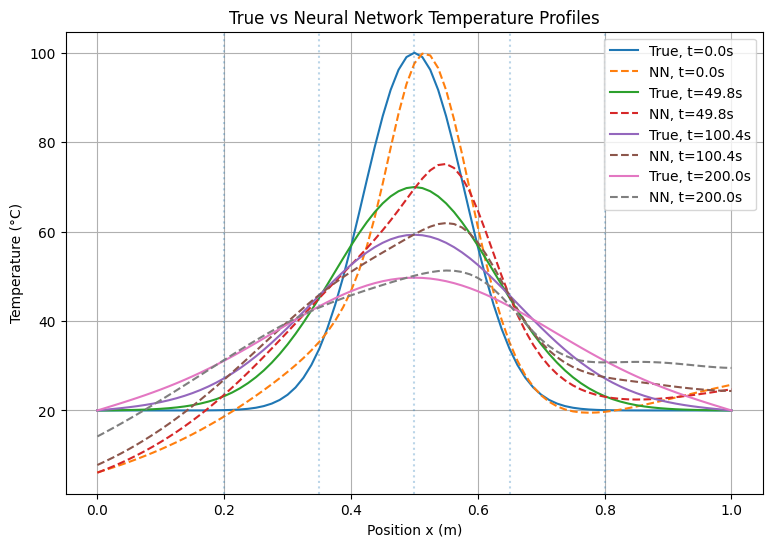

In [36]:
selected_times = [0, 50, 100, 200]

plt.figure(figsize=(9, 6))

for target_time in selected_times:

    time_index = np.argmin(
        np.abs(time_full - target_time)
    )

    plt.plot(
        x_full,
        T_true_full[time_index],
        label=f"True, t={time_full[time_index]:.1f}s"
    )

    plt.plot(
        x_full,
        T_pred_full[time_index],
        "--",
        label=f"NN, t={time_full[time_index]:.1f}s"
    )

plt.xlabel("Position x (m)")
plt.ylabel("Temperature (°C)")
plt.title("True vs Neural Network Temperature Profiles")

sensor_positions_plot = [
    0.20, 0.35, 0.50, 0.65, 0.80
]

for position in sensor_positions_plot:
    plt.axvline(
        position,
        linestyle=":",
        alpha=0.3
    )

plt.legend()
plt.grid()
plt.show()

## 13. Space-Time Reconstruction Error

The reconstruction error is examined across the complete space-time domain.

For each position and time,

$$
e(x,t)
=
\hat{T}(x,t)-T_{\text{true}}(x,t)
$$

Positive values indicate that the neural network overpredicts the temperature, while negative values indicate underprediction.

This visualization helps identify regions where the purely data-driven model has difficulty reconstructing the physical temperature field.

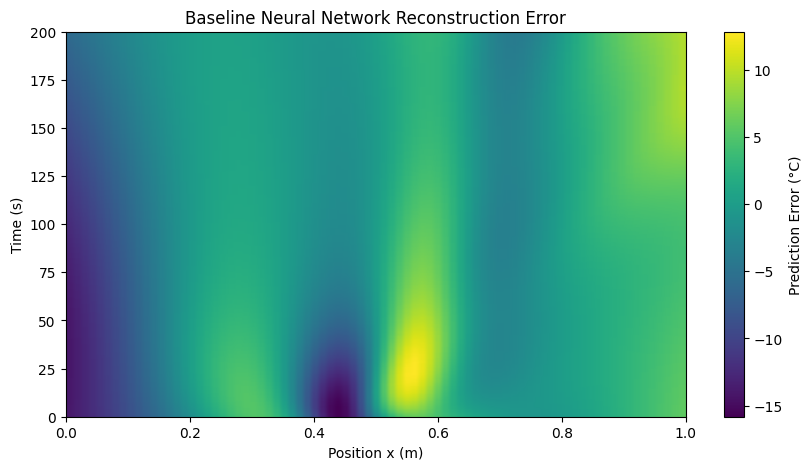

In [37]:
plt.figure(figsize=(10, 5))

plt.imshow(
    error_field,
    aspect="auto",
    origin="lower",
    extent=[
        x_full.min(),
        x_full.max(),
        time_full.min(),
        time_full.max()
    ]
)

plt.colorbar(
    label="Prediction Error (°C)"
)

plt.xlabel("Position x (m)")
plt.ylabel("Time (s)")
plt.title("Baseline Neural Network Reconstruction Error")

plt.show()

## 14. Baseline Model Summary

A fully connected neural network was trained using only sparse, noisy, and incomplete temperature-sensor measurements.

The model learned the overall evolution of the temperature field and achieved:

$$
RMSE = 4.6569^\circ C
$$

and

$$
MAE = 3.4224^\circ C
$$

over the complete simulated space-time domain.

The reconstruction was generally reasonable within the observed sensor region, but larger errors occurred where the spatial temperature field changed rapidly and in regions outside the sensor locations.

In particular, the data-driven model was not explicitly informed of the governing heat equation or the fixed-temperature boundary conditions.

This baseline therefore provides a reference for evaluating whether incorporating physical knowledge through a Physics-Informed Neural Network can improve full-field reconstruction from sparse sensor measurements.